In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('C:\\Users\\subham\\Desktop\\KNN Tekworks\\task1_dataset.csv')

In [4]:
df.head()

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,city,employment_type,loan_type,target
0,2020-01-01,63,63013.191704,279389.811431,616.029633,31,6.904324e+05,Bangalore,Unemployed,Auto,294319.227774
1,2020-01-02,20,47161.859481,950897.454063,716.561294,33,5.951086e+05,Bangalore,Student,Home,154516.648673
2,2020-01-03,46,55234.345094,NaN,564.991196,28,9.989912e+05,Delhi,Student,Auto,252354.507062
3,2020-01-04,52,74712.765160,431159.014692,572.736033,25,7.007800e+05,Chennai,Unemployed,Home,226719.203929
4,2020-01-05,56,82830.588108,272730.054365,813.630055,34,1.105784e+06,Delhi,Unemployed,Home,225838.346929


In [5]:
df.describe()

,age,income,loan_amount,credit_score,num_transactions,annual_spend,target
count,2000.000000,1920.000000,1.920000e+03,1920.000000,2000.00000,1.920000e+03,2000.000000
mean,43.569500,64111.180976,3.135794e+05,649.451886,30.13600,1.081605e+06,246455.466965
std,14.892786,35334.616365,1.415505e+05,80.483534,5.24006,7.028877e+05,66306.121409
min,18.000000,-5135.359342,-2.336766e+04,373.096400,14.00000,-1.461650e+05,13300.170171
25%,31.000000,46943.316170,2.337310e+05,594.475126,27.00000,7.887255e+05,201830.604797
50%,43.000000,60602.715999,3.041103e+05,649.578439,30.00000,1.004297e+06,245424.498558
75%,56.000000,75294.080356,3.722464e+05,703.239833,33.00000,1.214651e+06,292110.550126
max,69.000000,426093.266439,1.525158e+06,919.903709,52.00000,7.541094e+06,478502.472525


In [6]:
df.isnull().sum()

date                 0
age                  0
income              80
loan_amount         80
credit_score        80
num_transactions     0
annual_spend        80
city                 0
employment_type      0
loan_type            0
target               0
dtype: int64

In [10]:
# remove missing values using fillna and median of the columns income, loan_amount, credit_score and annual_spend
df['income'] = df['income'].fillna(df['income'].median())
df['loan_amount'] = df['loan_amount'].fillna(df['loan_amount'].median())
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df['annual_spend'] = df['annual_spend'].fillna(df['annual_spend'].median())


In [11]:
df.isnull().sum()

date                0
age                 0
income              0
loan_amount         0
credit_score        0
num_transactions    0
annual_spend        0
city                0
employment_type     0
loan_type           0
target              0
dtype: int64

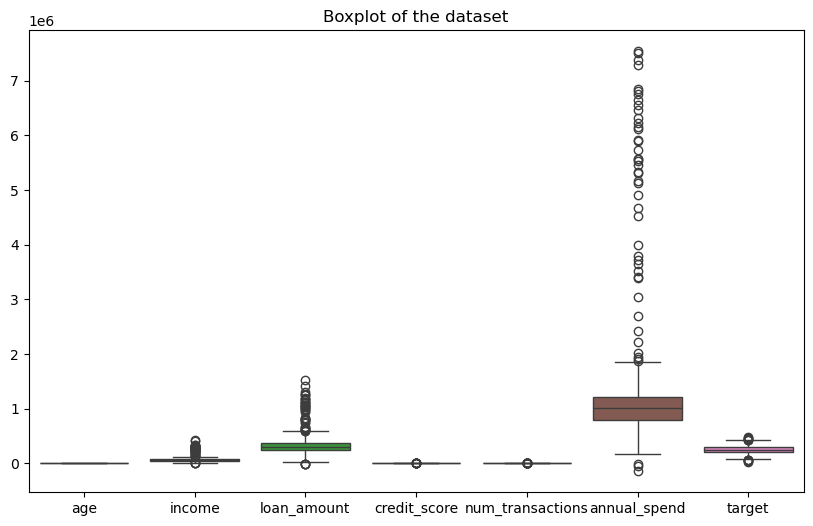

In [7]:
# check outliers using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of the dataset')
plt.show()

In [8]:
# Remove outliers using in income column using IQR method
Q1 = df['income'].quantile(0.25)
Q3 = df['income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['income'] >= lower_bound) & (df['income'] <= upper_bound)]


<Axes: ylabel='income'>

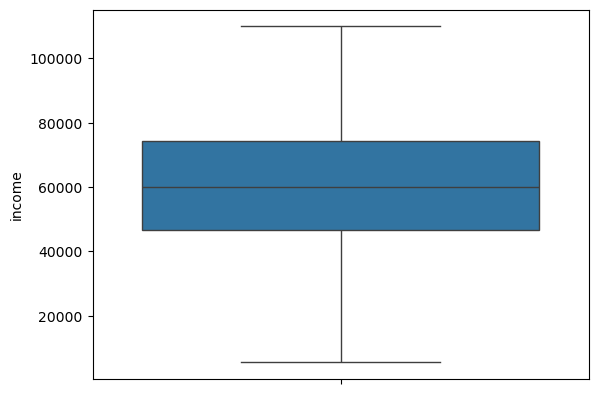

In [15]:
sns.boxplot(df['income'])

In [12]:
# Remove outliers in loan_amount column using IQR method
Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['loan_amount'] >= lower_bound) & (df['loan_amount'] <= upper_bound)]


<Axes: ylabel='loan_amount'>

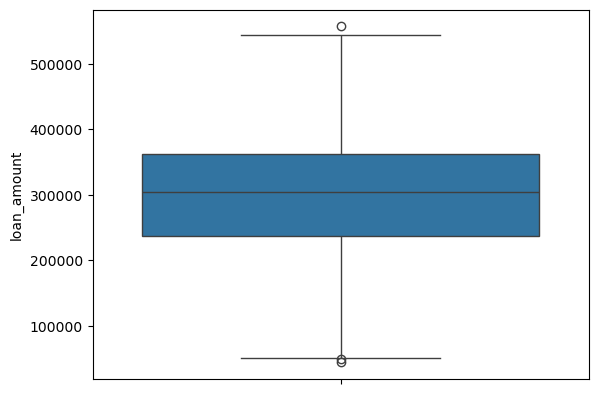

In [16]:
sns.boxplot(df['loan_amount'])

<Axes: ylabel='credit_score'>

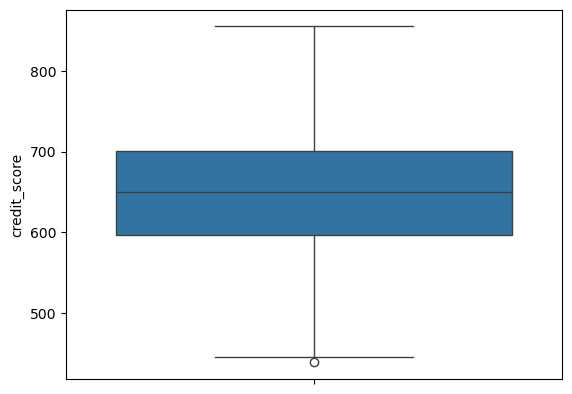

In [17]:
# Remove outliers from the credit_score column using IQR method
Q1 = df['credit_score'].quantile(0.25)
Q3 = df['credit_score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['credit_score'] >= lower_bound) & (df['credit_score'] <= upper_bound)]
sns.boxplot(df['credit_score'])

<Axes: ylabel='num_transactions'>

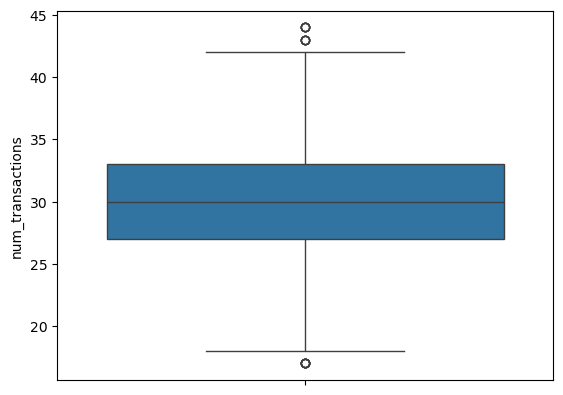

In [18]:
# Remove the outliers from num_transactions column using IQR method
Q1 = df['num_transactions'].quantile(0.25)
Q3 = df['num_transactions'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['num_transactions'] >= lower_bound) & (df['num_transactions'] <= upper_bound)]
sns.boxplot(df['num_transactions'])

<Axes: ylabel='annual_spend'>

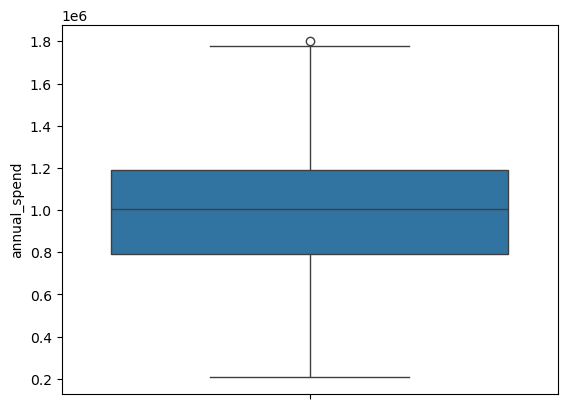

In [19]:
# Remove the outliers from the annual_spend column using IQR method
Q1 = df['annual_spend'].quantile(0.25)
Q3 = df['annual_spend'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['annual_spend'] >= lower_bound) & (df['annual_spend'] <= upper_bound)]
sns.boxplot(df['annual_spend'])

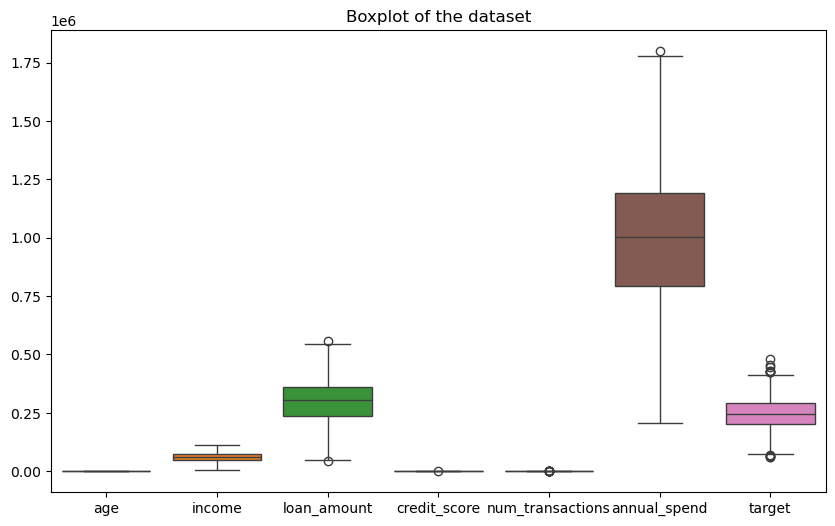

In [20]:
# check outliers using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot of the dataset')
plt.show()

In [26]:
encoded_cols=encoder.get_feature_names_out(cat)
encoded_df=pd.DataFrame(encoded_data,columns=encoded_cols)
df=df.drop(cat,axis=1)
df=pd.concat([df,encoded_df],axis=1)

In [27]:
encoded_df=pd.DataFrame(encoded_data,columns=encoder.get_feature_names_out(cat))
encoded_df

,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1742,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1743,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1744,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [28]:
df

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,...,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,2020-01-01,63.0,63013.191704,279389.811431,616.029633,31.0,6.904324e+05,294319.227774,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,2020-01-03,46.0,55234.345094,303726.287604,564.991196,28.0,9.989912e+05,252354.507062,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,2020-01-04,52.0,74712.765160,431159.014692,572.736033,25.0,7.007800e+05,226719.203929,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,2020-01-05,56.0,82830.588108,272730.054365,813.630055,34.0,1.105784e+06,225838.346929,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5,2020-01-06,35.0,51850.084382,358787.410069,653.483969,44.0,1.060460e+06,222714.888194,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [ ]:
# Drop the null values if any
df = df.dropna()


In [35]:
df

,date,age,income,loan_amount,credit_score,num_transactions,annual_spend,target,city_Bangalore,city_Chennai,...,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Student,employment_type_Unemployed,loan_type_Auto,loan_type_Education,loan_type_Home,loan_type_Personal
0,2020-01-01,63.0,63013.191704,279389.811431,616.029633,31.0,6.904324e+05,294319.227774,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,2020-01-03,46.0,55234.345094,303726.287604,564.991196,28.0,9.989912e+05,252354.507062,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,2020-01-04,52.0,74712.765160,431159.014692,572.736033,25.0,7.007800e+05,226719.203929,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,2020-01-05,56.0,82830.588108,272730.054365,813.630055,34.0,1.105784e+06,225838.346929,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5,2020-01-06,35.0,51850.084382,358787.410069,653.483969,44.0,1.060460e+06,222714.888194,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1739,2024-10-05,38.0,45820.314724,282005.252528,561.770575,36.0,6.544102e+05,301471.127349,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1740,2024-10-06,22.0,49056.895186,303726.287604,692.928818,23.0,1.165317e+06,260478.431551,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1741,2024-10-07,51.0,45271.863600,300838.005381,680.251069,29.0,4.503782e+05,197029.963900,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1742,2024-10-08,67.0,67523.717312,264380.867477,611.026223,32.0,9.945234e+05,201555.852305,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [36]:
df['month']=pd.to_datetime(df['date']).dt.month
df['day']=pd.to_datetime(df['date']).dt.day
df['year']=pd.to_datetime(df['date']).dt.year
df=df.drop('date',axis=1)

In [38]:
# find the skewness of the target variable
df['target'].skew()


np.float64(0.04719545490867898)

In [40]:
skew=df.drop(columns=['target']).skew()
skew

age                             -0.012791
income                           0.001053
loan_amount                     -0.034244
credit_score                    -0.011572
num_transactions                 0.093374
annual_spend                    -0.005142
city_Bangalore                   1.612176
city_Chennai                     1.547228
city_Delhi                       1.401795
city_Hyderabad                   1.430672
city_Mumbai                      1.526243
employment_type_Salaried         1.109171
employment_type_Self-Employed    1.029051
employment_type_Student          1.406567
employment_type_Unemployed       1.105263
loan_type_Auto                   1.177148
loan_type_Education              1.265536
loan_type_Home                   1.036513
loan_type_Personal               1.152814
month                            0.051256
day                              0.037542
year                             0.040277
dtype: float64

In [41]:
normal_skew_features=skew[skew==0].index.tolist()
positive_skew_features=skew[skew>0.5].index.tolist()
negative_skew_features=skew[skew<0.5].index.tolist()
print("Normal Skew Features:", normal_skew_features)
print("Positive Skew Features:", positive_skew_features)
print("Negative Skew Features:", negative_skew_features)

Normal Skew Features: []
Positive Skew Features: ['city_Bangalore', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Student', 'employment_type_Unemployed', 'loan_type_Auto', 'loan_type_Education', 'loan_type_Home', 'loan_type_Personal']
Negative Skew Features: ['age', 'income', 'loan_amount', 'credit_score', 'num_transactions', 'annual_spend', 'month', 'day', 'year']


In [42]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scale=MinMaxScaler()

In [43]:
normal_skew=['income','loan_amount']
df[normal_skew]=scale.fit_transform(df[normal_skew])

In [44]:
scaler=StandardScaler()
df['credit_score']=scaler.fit_transform(df[['credit_score']])

In [45]:
#import train test split
from sklearn.model_selection import train_test_split
X=df.drop(columns=['target'])
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [46]:
#after splitting the data we can apply knn regression model
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 3970491912.9637394


In [47]:
#find R2 score
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:", r2)

R2 Score: 0.1643254403187071


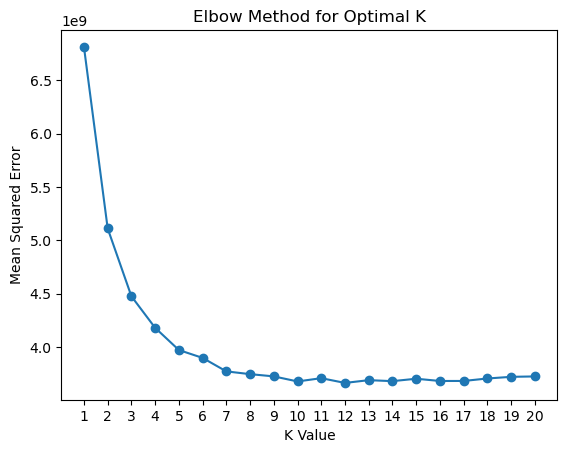

In [48]:
mse_values=[]
k_values=range(1,21)
for k in k_values:
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    mse=mean_squared_error(y_test,y_pred)
    mse_values.append(mse)
plt.plot(k_values,mse_values,marker='o')
plt.xlabel('K Value')
plt.ylabel('Mean Squared Error')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_values)
plt.show()

In [49]:
##use linear regression model to compare the performance of knn regression model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)
mse_lr=mean_squared_error(y_test,y_pred_lr)
print("Mean Squared Error for Linear Regression:", mse_lr)

Mean Squared Error for Linear Regression: 2737565282.413942


In [50]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R2 Score:", r2)
r2_lr=r2_score(y_test,y_pred_lr)
print("R2 Score for Linear Regression:", r2_lr)

R2 Score: 0.21643326045973765
R2 Score for Linear Regression: 0.4238211002242236


In [51]:
## use decision tree regression model to compare the performance of knn regression model
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
mse_dt=mean_squared_error(y_test,y_pred_dt)
print("Mean Squared Error for Decision Tree Regression:", mse_dt)
r2_dt=r2_score(y_test,y_pred_dt)
print("R2 Score for Decision Tree Regression:", r2_dt)

Mean Squared Error for Decision Tree Regression: 5191930559.619035
R2 Score for Decision Tree Regression: -0.09275232878307316
